Mutual Information Scores:
 Year_Built        0.104752
Nearby_Schools    0.042483
Condition         0.029914
Total_Rooms       0.028443
Garage_Size       0.027819
Area_sqft         0.017115
House_Type        0.000000
Location          0.000000
Transaction       0.000000
Has_Garden        0.000000
Name: MI Scores, dtype: float64


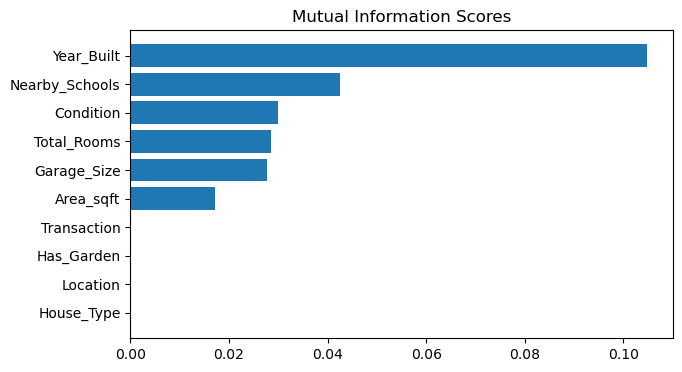

C:\Users\HP\AppData\Local\Temp\ipykernel_3456\2881431314.py:70: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




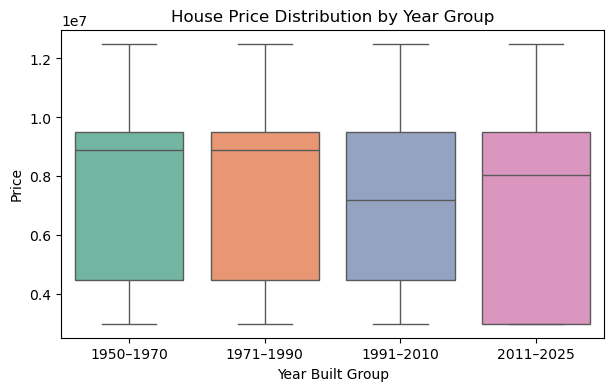

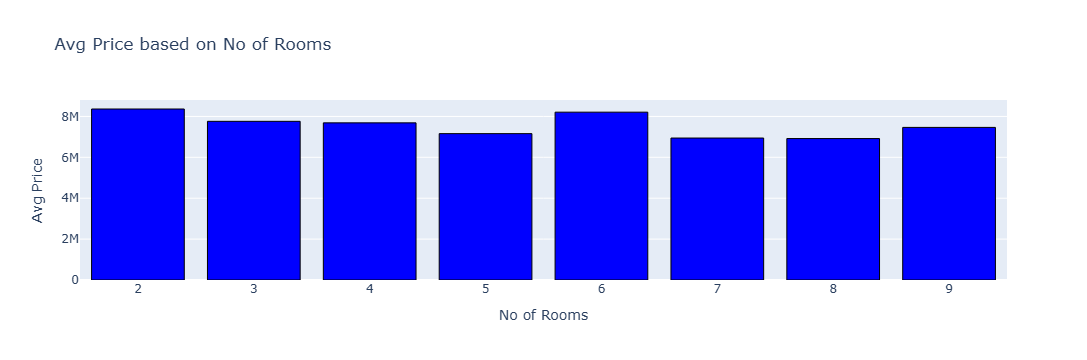

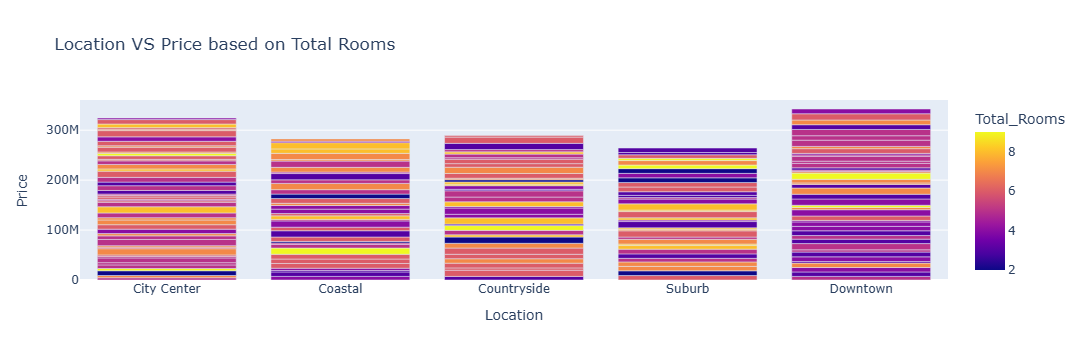

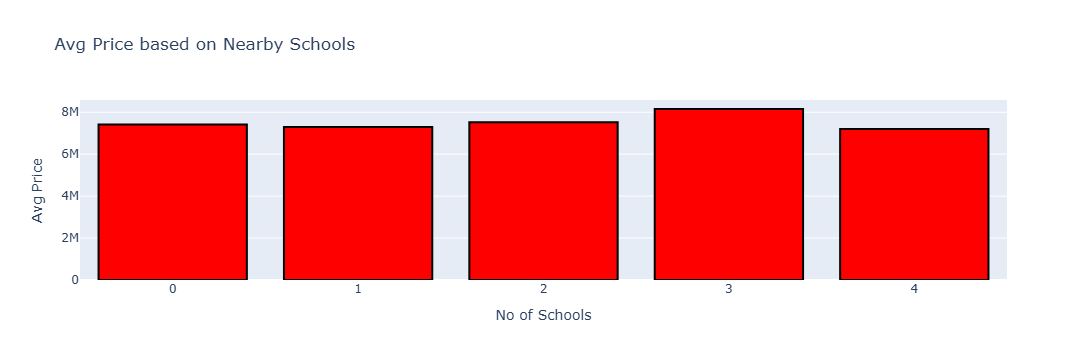

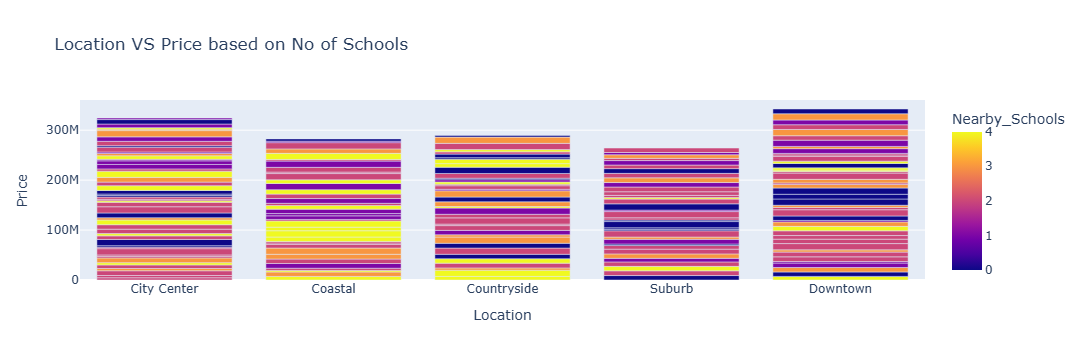

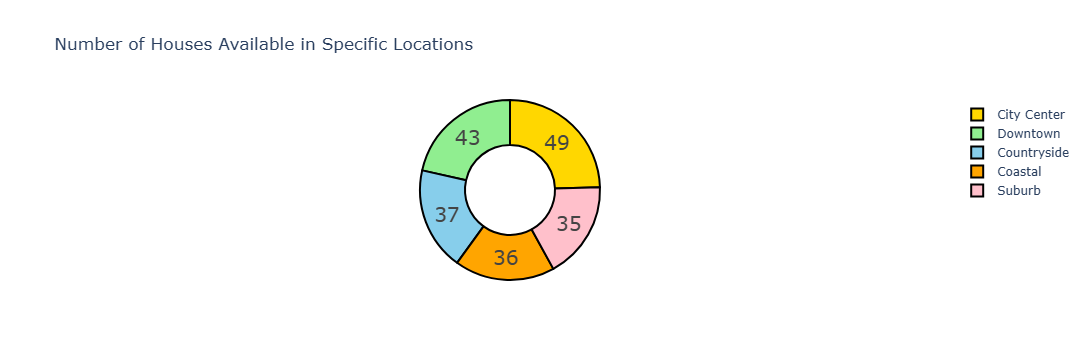

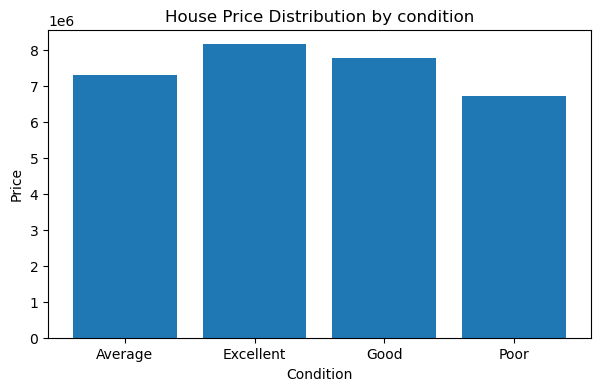

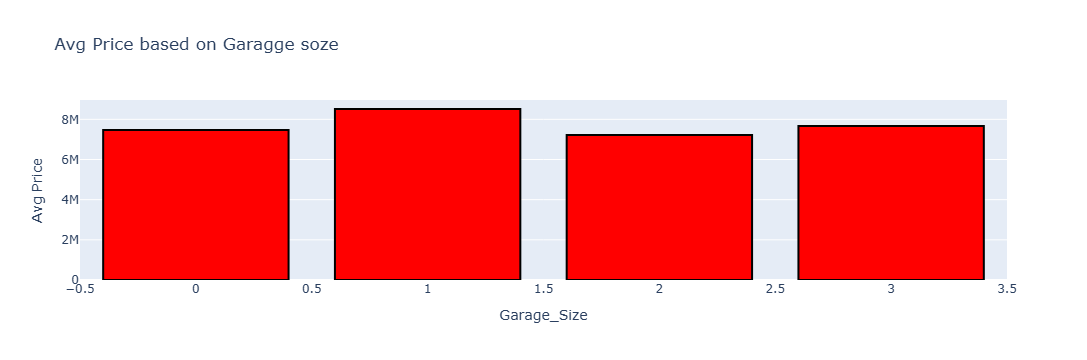

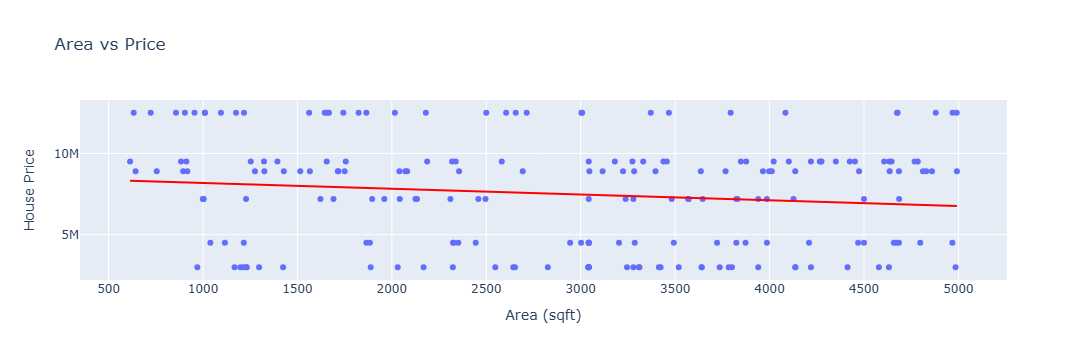

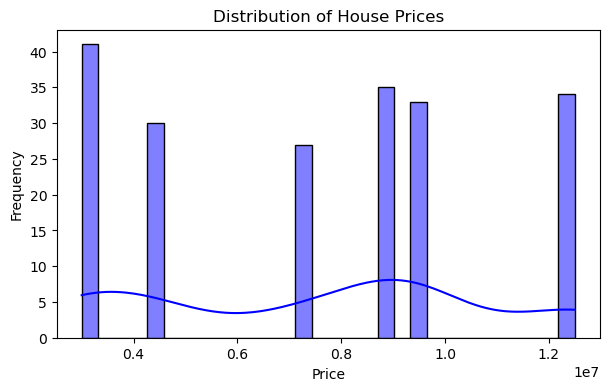

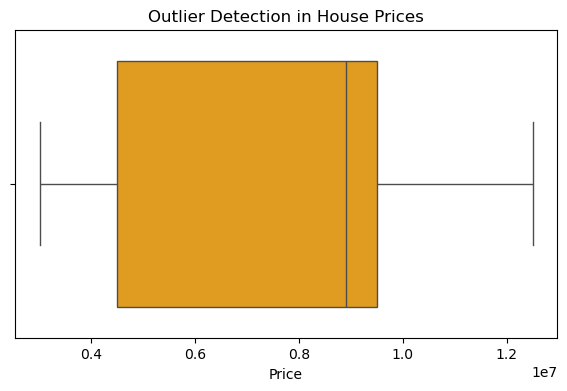

Model Training Completed ✅

--- Enter House Details for Prediction ---



Enter Location (City center/Downtown/Coastal/Countryside/Suburb):  City center
Enter House Type (Apartment/Villa/Studio/Other):  Apartment
Enter Condition (New/Good/Average/Old):  New
Enter Transaction Type (Sale/Rent):  Rent
Enter Area in sqft:  3456
Enter Year Built:  2011
Enter Garage Size (0,1,2,...):  1
Has Garden? (Yes/No):  Yes
Enter Total Rooms:  3
Enter Nearby Schools:  1



🏠 Predicted House Price: 12,248,668.28


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# ----------------- Fix global randomness -----------------
np.random.seed(42)

# ----------------- Load dataset -----------------
df = pd.read_csv("HousePriceDataset.csv")

# ---------------- Handle categorical column -----------------
"""df['Has_Garden'] = df['Has_Garden'].astype(str).str.strip()
df['Has_Garden'] = df['Has_Garden'].replace("nan", pd.NA)  # Convert 'nan' strings to real NaN
df['Has_Garden'] = df['Has_Garden'].fillna(df['Has_Garden'].mode()[0])

# ----------------- Ensure numeric columns are correct -----------------
df['Nearby_Schools'] = pd.to_numeric(df['Nearby_Schools'], errors='coerce')

# ----------------- Fill missing numeric values with median -----------------
for col in ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Garage_Size', 'Nearby_Schools']:
    df[col] = df[col].fillna(df[col].median())

# ----------------- Feature Engineering -----------------
#df['Total_Rooms'] = df['Bedrooms'] + df['Bathrooms']"""

# ----------------- Stable MI Calculation -----------------
X = df.copy()
y = X.pop("Price")

# Factorize categorical columns
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

discrete_features = X.dtypes == int

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=42)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)
print("Mutual Information Scores:\n", mi_scores)

# ----------------- Plot MI Scores -----------------
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")
    plt.show()

plt.figure(dpi=100, figsize=(7, 4))
plot_mi_scores(mi_scores)

# ----------------- Year Built Grouping & Boxplot -----------------
df['Year_Group'] = pd.cut(df['Year_Built'], 
                          bins=[1950, 1970, 1990, 2010, 2025], 
                          labels=["1950–1970", "1971–1990", "1991–2010", "2011–2025"])

plt.figure(figsize=(7,4))
sns.boxplot(x="Year_Group", y="Price", data=df, palette="Set2")
plt.title("House Price Distribution by Year Group")
plt.ylabel("Price")
plt.xlabel("Year Built Group")
plt.show()

# ----------------- Average Price by Total Rooms -----------------
Room_Cat = df.groupby("Total_Rooms")['Price'].mean().reset_index()
fig = px.bar(Room_Cat,
             x="Total_Rooms",
             y="Price",
             title="Avg Price based on No of Rooms",
             labels={"Total_Rooms": "No of Rooms", "Price": "Avg Price"},
             hover_data={"Total_Rooms": True, "Price": ":,.0f"})
fig.update_traces(marker_color="blue", marker_line_color="black", marker_line_width=1)
fig.show()

# ----------------- Location vs Price based on Total Rooms -----------------
fig = px.bar(df,
             x="Location",
             y="Price",
             color="Total_Rooms",
             title="Location VS Price based on Total Rooms")
fig.show()

# ----------------- Average Price by Nearby Schools -----------------
Nearbyschool_Cat = df.groupby("Nearby_Schools")['Price'].mean().reset_index()
fig = px.bar(Nearbyschool_Cat,
             x="Nearby_Schools",
             y="Price",
             title="Avg Price based on Nearby Schools",
             labels={"Nearby_Schools": "No of Schools", "Price": "Avg Price"},
             hover_data={"Nearby_Schools": True, "Price": ":,.0f"})
fig.update_traces(marker_color="red", marker_line_color="black", marker_line_width=2)
fig.show()

# ----------------- Location vs Price based on Nearby Schools -----------------
fig = px.bar(df,
             x="Location",
             y="Price",
             color="Nearby_Schools",
             title="Location VS Price based on No of Schools")
fig.show()

# ----------------- Pie chart for number of houses in each location -----------------
loc = df['Location'].value_counts()
label = loc.index
counts = loc.values
colors = ['gold', 'lightgreen', 'skyblue', 'orange', 'pink'][:len(label)]  # flexible colors

fig = go.Figure(data=[go.Pie(labels=label, values=counts, hole=0.5)])
fig.update_layout(title_text='Number of Houses Available in Specific Locations')
fig.update_traces(
    hoverinfo='label+percent',
    textinfo='value',
    textfont_size=20,
    marker=dict(colors=colors, line=dict(color='black', width=2))
)
fig.show()

# ----------------- Bar chart for Price based on condition of house -----------------
conditon_category=df.groupby("Condition")['Price'].mean()
plt.figure(figsize=(7,4))
plt.bar(conditon_category.index,conditon_category.values)
plt.title("House Price Distribution by condition")
plt.ylabel("Price")
plt.xlabel("Condition")
plt.show()

# ----------------- Bar chart for Price based on Garage Size -----------------
Garage_capacity = df.groupby("Garage_Size")['Price'].mean().reset_index()
fig = px.bar(Garage_capacity,
             x="Garage_Size",
             y="Price",
             title="Avg Price based on Garagge soze",
             labels={"Garagge_Size": "Garage Capacity", "Price": "Avg Price"},
             hover_data={"Garage_Size": True, "Price": ":,.0f"})
fig.update_traces(marker_color="red", marker_line_color="black", marker_line_width=2)
fig.show()

# ----------------- Scatter Plot for Price based on Area -----------------
fig = px.scatter(
    df,
    x="Area_sqft",   # replace with your column name for area
    y="Price",       # use original Price (not normalized one)
    title="Area vs Price",
    labels={"Area_sqft": "Area (sqft)", "Price": "House Price"},
    hover_data={"Area_sqft": True, "Price": ":,.0f"},  # show values on hover (Price formatted with commas)
    trendline="ols",   # Ordinary Least Squares Regression
    trendline_color_override="red"
)

fig.show()

# ----------------- Distribution Plot of Price -----------------
plt.figure(figsize=(7,4))
sns.histplot(df['Price'], kde=True, bins=30, color="blue")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# ----------------- Outlier Detection -----------------
plt.figure(figsize=(7,4))
sns.boxplot(x=df['Price'], color="orange")
plt.title("Outlier Detection in House Prices")
plt.xlabel("Price")
plt.show()


# ============================================================
# ----------------- MODEL TRAINING -----------------
# ============================================================

# Encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop("Price", axis=1)
y = df_encoded["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Training Completed ✅")

# ============================================================
# ----------------- USER INPUT & PREDICTION -----------------
# ============================================================

# Ask user for details
print("\n--- Enter House Details for Prediction ---\n")

location = input("Enter Location (City center/Downtown/Coastal/Countryside/Suburb): ")
house_type = input("Enter House Type (Apartment/Villa/Studio/Other): ")
condition = input("Enter Condition (New/Good/Average/Old): ")
transaction = input("Enter Transaction Type (Sale/Rent): ")

area_sqft = float(input("Enter Area in sqft: "))
year_built = int(input("Enter Year Built: "))
garage_size = int(input("Enter Garage Size (0,1,2,...): "))
has_garden = input("Has Garden? (Yes/No): ")
total_rooms = int(input("Enter Total Rooms: "))
nearby_schools = int(input("Enter Nearby Schools: "))

# Convert to dataframe
house = pd.DataFrame({
    "Area_sqft": [area_sqft],
    "Year_Built": [year_built],
    "Garage_Size": [garage_size],
    "Has_Garden": [has_garden],
    "Total_Rooms": [total_rooms],
    "Nearby_Schools": [nearby_schools],
    "Location": [location],
    "House_Type": [house_type],
    "Condition": [condition],
    "Transaction": [transaction]
})

# One-hot encode user input same as training data
house_encoded = pd.get_dummies(house, drop_first=True)

# Align with training features
house_encoded = house_encoded.reindex(columns=X.columns, fill_value=0)

# Predict
predicted_price = model.predict(house_encoded)[0]
print(f"\n🏠 Predicted House Price: {predicted_price:,.2f}")
